In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import geopandas as gpd
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score, cross_validate
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import datetime as dt
warnings.filterwarnings("ignore") # specify to ignore warning messages

In [2]:
attribBaso = "Shapefiles/attribBasoPolygons_with_point_counts.shp"
attribBasoPolygons = gpd.read_file(attribBaso)
attribBasoPolygons.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 58 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   AREA        419 non-null    float64 
 1   PERIMETER   419 non-null    float64 
 2   BAS2000_    419 non-null    float64 
 3   BAS2000_ID  419 non-null    float64 
 4   KOMMUN_NR   419 non-null    int64   
 5   KOMKOD      419 non-null    int64   
 6   KOMKOD2     419 non-null    int64   
 7   BASKOD90    419 non-null    int64   
 8   BASKOD95    419 non-null    int64   
 9   BASKOD97    419 non-null    int64   
 10  BASKOD99    419 non-null    int64   
 11  BASKOD2000  419 non-null    int64   
 12  BASN2010    419 non-null    object  
 13  KOMMENT     25 non-null     object  
 14  BASKOD2010  419 non-null    int64   
 15  KOM_2       17 non-null     object  
 16  Regkarna    230 non-null    object  
 17  Stadsbygd   419 non-null    object  
 18  ID          419 non-null    int64   
 19  

In [3]:
attribBasoPolygons['ID'].nunique()

419

Cross-validated R² scores: [0.73859595 0.53998896 0.34472734 0.6528078  0.53055156]
Mean R²: 0.561


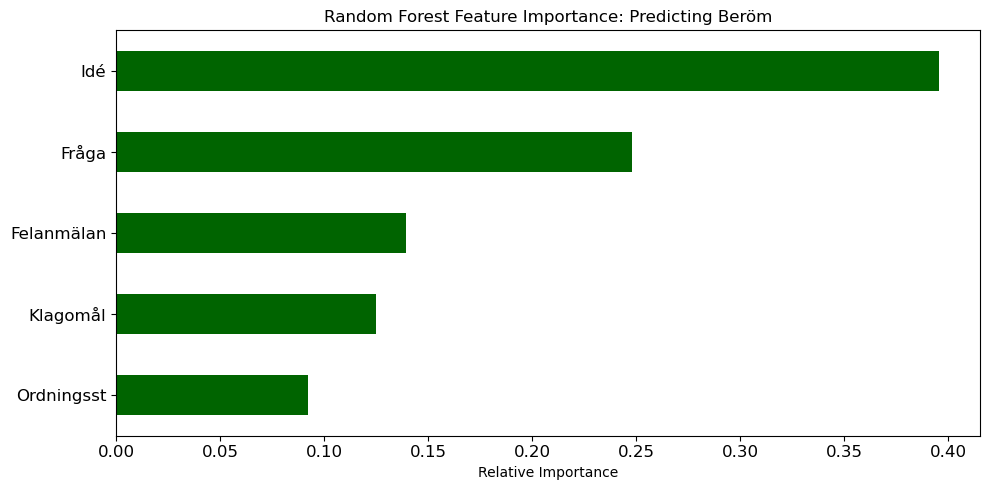

In [51]:
predictor_cols = ['Felanmälan', 'Klagomål', 'Ordningsst', 'Idé', 'Fråga']

attribBasoPolygons['X'] = attribBasoPolygons.geometry.centroid.x
attribBasoPolygons['Y'] = attribBasoPolygons.geometry.centroid.y

df_model = attribBasoPolygons.dropna(subset=predictor_cols + ['Beröm']).copy()

X = df_model[predictor_cols]
y = df_model['Beröm']

rf = RandomForestRegressor(n_estimators=500, max_depth=8, random_state=42)
rf.fit(X, y)

scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {scores}")
print(f"Mean R²: {scores.mean():.3f}")

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 3))
importances.plot(kind='barh', color='darkgreen')
plt.title("Random Forest Feature Importance: Predicting Beröm")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.savefig("berom_rf_feature_importance.png", dpi=300)
plt.show()

# Landuse

In [5]:
# Building Use
os.chdir(r'C:\Users\omkarp\Downloads\Newer\python\Shapefiles\Landuse')
pois1 = gpd.read_file('BU_POI.shp')
pois1 = pois1.drop(columns=['FID_gis_os', 'osm_id', 'code', 'fclass', 'name', 'FID_Kommun','sub_c_type', 'KOMKOD', 'Shape_Leng', 'ORIG_FID'])
pois1.head()

,type,geometry
0,office,POINT Z (18.14848 59.32547 0.00000)
1,school,POINT Z (18.13331 59.32358 0.00000)
2,school,POINT Z (18.13276 59.32457 0.00000)
3,school,POINT Z (18.13232 59.32464 0.00000)
4,None,POINT Z (18.13543 59.33536 0.00000)


In [6]:
if pois1.crs is None:
    pois1.set_crs(attribBasoPolygons.crs, inplace=True)
elif pois1.crs != attribBasoPolygons.crs:
    pois1 = pois1.to_crs(attribBasoPolygons.crs)

pois1_ID = gpd.sjoin(
    pois1,
    attribBasoPolygons[['ID', 'geometry']],
    how="left",
    predicate="within"
)

pois1_ID = pois1_ID.drop(columns=["index_right"])
# pois1_with_ID.to_file("pois1_ID.shp")
pois1_ID.head()

,type,geometry,ID
0,office,POINT Z (158452.980 6578935.210 0.000),1230220.0
1,school,POINT Z (157590.280 6578722.671 0.000),1230220.0
2,school,POINT Z (157558.683 6578833.211 0.000),1230220.0
3,school,POINT Z (157533.565 6578841.137 0.000),1230220.0
4,None,POINT Z (157708.056 6580035.312 0.000),1230390.0


In [7]:
pois1_ID['type'].unique()

array(['office', 'school', None, 'apartments', 'residential',
       'restaurant', 'cafe', 'sports_centre', 'commercial', 'house',
       'detached', 'public', 'kindergarten', 'transportation', 'service',
       'retail', 'industrial', 'supermarket', 'parking', 'terrace',
       'garages', 'roof', 'stable', 'greenhouse', 'hut', 'shed', 'garage',
       'sports_hall', 'church', 'hotel', 'museum', 'embassy',
       'storage_tank', 'military', 'warehouse', 'theatre',
       'farm_auxiliary', 'gazebo', 'train_station', 'bunker', 'kiosk',
       'chicken_coop', 'gasometer', 'university', 'riding_school',
       'hospital', 'college', 'toilets', 'windmill', 'pavilion',
       'government', 'barn', 'dormitory', 'palace', 'ruins', 'civic',
       'hangar', 'stadium', 'construction', 'concert_hall', 'ship',
       'tower', 'depot', 'chapel', 'semidetached_house', 'container',
       'cultural', 'synagogue', 'mosque', 'fire_station', 'boat', 'power',
       'power_station', 'grandstand', 'chimne

In [8]:
def merge_fclasses(fclass):
    if fclass in ['bungalow','allotment_house','mixed','semidetached_house','detached', 'dormitory','hut','semi','house',
                  'residential','apartments','cabin','shelter']:
        return 'LUP_Resi'
    elif fclass in ['retail','supermarket','hotel','hangar','factory','store','industrial','office','nursery','commercial',
                    'restaurant','warehouse','cafe']:
        return 'LUP_Comm'
    elif fclass in ['sports_hall','park','theatre','church','religious','kiosk','cathedral','social_facility','subway_station',
                    'cultural','palace','gazebo','sport', 'sports_centre','theatre','stadium','ruins','synagogue','chapel',
                    'pavilion','mosque','cinema','museum','conference_centre','concert_hall','riding_hall', 'houseboat',
                    'boathouse']:
        return 'LUP_Recre'
    elif fclass in ['university','school','college','hostel','kindergarten','riding_school']:
        return 'LUP_Edu'
    elif fclass in ['train_station','civic','library','community_centre','bank','atm','post_office','government','public','railway_station','depot','observatory','embassy', 'parking']:
        return 'LUP_Public'
    elif fclass in ['hospital', 'clinic']:
        return 'LUP_Health'
    else:
        return 'LUP_Other'
    
pois1_ID['major_clas'] = pois1_ID['type'].apply(merge_fclasses)
pois1_ID.head()

,type,geometry,ID,major_clas
0,office,POINT Z (158452.980 6578935.210 0.000),1230220.0,LUP_Comm
1,school,POINT Z (157590.280 6578722.671 0.000),1230220.0,LUP_Edu
2,school,POINT Z (157558.683 6578833.211 0.000),1230220.0,LUP_Edu
3,school,POINT Z (157533.565 6578841.137 0.000),1230220.0,LUP_Edu
4,None,POINT Z (157708.056 6580035.312 0.000),1230390.0,LUP_Other


In [9]:
pois1_ID['count']=1
result1 = pois1_ID.groupby(['ID', 'major_clas']).agg({'count': 'sum'})
result1 = result1.reset_index(drop = False)
result1['LUP_Comm'] = result1['count'][result1['major_clas'] == 'LUP_Comm']
result1['LUP_Other'] = result1['count'][result1['major_clas'] == 'LUP_Other']
result1['LUP_Recre'] = result1['count'][result1['major_clas'] == 'LUP_Recre']
result1['LUP_Public'] = result1['count'][result1['major_clas'] == 'LUP_Public']
result1['LUP_Resi'] = result1['count'][result1['major_clas'] == 'LUP_Resi']
result1['LUP_Edu'] = result1['count'][result1['major_clas'] == 'LUP_Edu']
result1['LUP_Health'] = result1['count'][result1['major_clas'] == 'LUP_Health']

result1 = result1.drop(columns=['major_clas', 'count'])
result1 = result1.groupby(['ID']).sum()
result1.sum()

LUP_Comm       1283.0
LUP_Other     37604.0
LUP_Recre       234.0
LUP_Public      143.0
LUP_Resi      32457.0
LUP_Edu         914.0
LUP_Health       39.0
dtype: float64

### Landuse

In [10]:
#OnlyLanduse
os.chdir(r'C:\Users\omkarp\Downloads\Newer\python\Shapefiles\Landuse')
pois2 = gpd.read_file('LU_POI.shp')
pois2 = pois2.drop(columns=['FID_gis_os','osm_id','code','name','FID_Kommun','sub_c_type','KOMKOD'])
pois2.head()

,fclass,geometry
0,restaurant,POINT Z (18.08676 59.34204 0.00000)
1,supermarket,POINT Z (18.09110 59.34235 0.00000)
2,recycling,POINT Z (18.05410 59.37070 0.00000)
3,recycling_glass,POINT Z (18.08455 59.36433 0.00000)
4,zoo,POINT Z (18.07105 59.36559 0.00000)


In [11]:
if pois2.crs is None:
    pois2.set_crs(attribBasoPolygons.crs, inplace=True)
elif pois2.crs != attribBasoPolygons.crs:
    pois2 = pois2.to_crs(attribBasoPolygons.crs)

# 3. Spatial join: bring in the 'ID' field from the polygon each point falls within
pois2_ID = gpd.sjoin(
    pois2,
    attribBasoPolygons[['ID', 'geometry']],
    how="left",
    predicate="within"
)

pois2_ID = pois2_ID.drop(columns=["index_right"])
# pois2_with_ID.to_file("pois2_ID.shp")
pois2_ID.head()

,fclass,geometry,ID
0,restaurant,POINT Z (154936.903 6580775.201 0.000),1230310.0
1,supermarket,POINT Z (155184.207 6580810.177 0.000),1230310.0
2,recycling,POINT Z (153075.995 6583965.194 0.000),1210320.0
3,recycling_glass,POINT Z (154807.954 6583257.603 0.000),1210350.0
4,zoo,POINT Z (154040.083 6583396.916 0.000),1210350.0


In [12]:
def merge_fclasses(fclass):
    if fclass in ['shelter','chalet']:
        return 'LUP_Resi'
    elif fclass in ['hotel','restaurant','bicycle_shop','fast_food','cafe','bar','supermarket','convenience','department_store',
                    'mall','pub','motel','outdoor_shop','bookshop','clothes','optician','car_rental','nightclub','bakery',
                    'laundry','hairdresser','beverages','florist','travel_agent','biergarten','furniture_shop','stationery',
                    'recycling_clothes','bicycle_rental','food_court','beauty_shop','doityourself','video_shop','sports_shop',
                    'mobile_phone_shop','shoe_shop','jeweller','toy_shop','car_dealership','gift_shop','greengrocer','butcher',
                    'computer_shop','vending_parking','vending_machine','vending_any','car_wash']:
        return 'LUP_Comm'
    elif fclass in ['garden_centre','park','theatre','tourist_info','cinema','playground','sports_centre','attraction',
                    'picnic_site','zoo','fountain','viewpoint','artwork','kiosk','archaeological','ruins','arts_centre',
                    'drinking_water','car_sharing','theme_park']:
        return 'LUP_Recre'
    elif fclass in ['university','school','college','hostel','kindergarten','riding_school']:
        return 'LUP_Edu'
    elif fclass in ['community_centre','bank','atm','post_office','museum','monument','memorial,''toilet','library',
                    'embassy','police','post_box','fire_station','courthouse']:
        return 'LUP_Public'
    elif fclass in ['hospital', 'clinic']:
        return 'LUP_Health'
    else:
        return 'LUP_Other'
    
pois2_ID['major_clas'] = pois2_ID['fclass'].apply(merge_fclasses)
pois2_ID.head()

,fclass,geometry,ID,major_clas
0,restaurant,POINT Z (154936.903 6580775.201 0.000),1230310.0,LUP_Comm
1,supermarket,POINT Z (155184.207 6580810.177 0.000),1230310.0,LUP_Comm
2,recycling,POINT Z (153075.995 6583965.194 0.000),1210320.0,LUP_Other
3,recycling_glass,POINT Z (154807.954 6583257.603 0.000),1210350.0,LUP_Other
4,zoo,POINT Z (154040.083 6583396.916 0.000),1210350.0,LUP_Recre


In [13]:
pois2_ID['count']=1
result2 = pois2_ID.groupby(['ID', 'major_clas']).agg({'count': 'sum'})
result2 = result2.reset_index(drop = False)
result2['LUP_Comm'] = result2['count'][result2['major_clas'] == 'LUP_Comm']
result2['LUP_Other'] = result2['count'][result2['major_clas'] == 'LUP_Other']
result2['LUP_Recre'] = result2['count'][result2['major_clas'] == 'LUP_Recre']
result2['LUP_Public'] = result2['count'][result2['major_clas'] == 'LUP_Public']
result2['LUP_Resi'] = result2['count'][result2['major_clas'] == 'LUP_Resi']
result2['LUP_Edu'] = result2['count'][result2['major_clas'] == 'LUP_Edu']
result2['LUP_Health'] = result2['count'][result2['major_clas'] == 'LUP_Health']

result2 = result2.drop(columns=['major_clas', 'count'])
result2 = result2.groupby(['ID']).sum()
result = result1.add(result2, fill_value=0)
result.sum()

LUP_Comm       8127.0
LUP_Other     42744.0
LUP_Recre      1797.0
LUP_Public      943.0
LUP_Resi      32485.0
LUP_Edu        1149.0
LUP_Health       82.0
dtype: float64

In [14]:
mix=result.loc[:,['LUP_Resi','LUP_Comm','LUP_Edu','LUP_Recre','LUP_Public','LUP_Health','LUP_Other']]
weight = list(mix.sum(axis=0).sum()/mix.sum(axis=0))
c = np.log(weight)
# print(c)
mix.iloc[0:len(mix),0] = mix.iloc[0:len(mix),0]*c[0]
mix.iloc[0:len(mix),1] = mix.iloc[0:len(mix),1]*c[1]
mix.iloc[0:len(mix),2] = mix.iloc[0:len(mix),2]*c[2]
mix.iloc[0:len(mix),3] = mix.iloc[0:len(mix),3]*c[3]
mix.iloc[0:len(mix),4] = mix.iloc[0:len(mix),4]*c[4]
mix.iloc[0:len(mix),5] = mix.iloc[0:len(mix),5]*c[5]
mix.iloc[0:len(mix),6] = mix.iloc[0:len(mix),6]*c[6]
mix['all'] = mix.sum(axis=1)
mix.loc[:,'LUP_Resi':'LUP_Other'] = mix.loc[:,'LUP_Resi':'LUP_Other'].div(mix['all'], axis=0)+0.00001
mix = mix.astype(float)
mix.fillna(0, inplace=True)
mix.describe(include='all')
mix2 = mix
def func (x):
    y = x*np.log(x)
    return y
mix2 = mix2.loc[:,'LUP_Resi':'LUP_Other'].applymap(func)/(-np.log(5))
mix2['entropy'] = mix2.loc[:,'LUP_Resi':'LUP_Other'].sum(axis=1)
mix['entropy'] = mix2['entropy']
mix['Resi_lur'] = mix['LUP_Resi']
mix['Comm_lur'] = mix['LUP_Comm']
mix['Edu_lur'] = mix['LUP_Edu']
mix['Recre_lur'] = mix['LUP_Recre']
mix['Public_lur'] = mix['LUP_Public']
mix['Health_lur'] = mix['LUP_Health']
mix['Other_lur'] = mix['LUP_Other']
mix = mix.drop(['LUP_Resi', 'LUP_Comm', 'LUP_Edu', 'LUP_Recre', 'LUP_Public','LUP_Health', 'LUP_Other','all'], axis=1)
mix = mix.reset_index(drop=False)
mix

,ID,entropy,Resi_lur,Comm_lur,Edu_lur,Recre_lur,Public_lur,Health_lur,Other_lur
0,1010110.0,0.871898,0.004053,0.252388,0.000010,0.238149,0.222153,0.000010,0.283308
1,1010120.0,0.856438,0.056766,0.488351,0.020724,0.130031,0.064986,0.000010,0.239202
2,1010130.0,0.759375,0.126194,0.614898,0.016263,0.043735,0.110477,0.000010,0.088492
3,1010140.0,0.898763,0.262478,0.441170,0.047904,0.103086,0.030058,0.000010,0.115364
4,1010201.0,0.750783,0.045742,0.571021,0.000010,0.107769,0.209428,0.000010,0.066089
...,...,...,...,...,...,...,...,...,...
414,2250340.0,0.507422,0.180628,0.025521,0.037234,0.016700,0.000010,0.000010,0.739966
415,2250350.0,0.968051,0.264289,0.085136,0.197615,0.012667,0.059044,0.022729,0.358590
416,2250360.0,0.584238,0.013778,0.099188,0.000010,0.270359,0.000010,0.000010,0.616716
417,2250370.0,0.182734,0.086151,0.000010,0.000010,0.000010,0.000010,0.000010,0.913869


In [15]:
os.chdir(r'C:\Users\omkarp\Downloads\Newer\python\Shapefiles')
attribBaso = "attribBasoPolygons_with_point_counts.shp"
data = gpd.read_file(attribBaso)
data = data.drop(columns=['PERIMETER', 'BAS2000_', 'BAS2000_ID', 'KOMMUN_NR', 'KOMKOD', 'KOMKOD2', 'BASKOD90', 'BASKOD95', 'BASKOD97', 
                            'BASKOD99', 'BASKOD2000','BASN2010', 'KOMMENT', 'BASKOD2010', 'KOM_2', 'Regkarna', 'Stadsbygd','Pop_16', 
                            'Pop_15', 'Pop_10', 'Pop_05','Pop_00'])
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 36 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   AREA        419 non-null    float64 
 1   ID          419 non-null    int64   
 2   Name        419 non-null    object  
 3   Pop_17      419 non-null    int64   
 4   Male        419 non-null    int64   
 5   Female      419 non-null    int64   
 6   Males_15_3  419 non-null    int64   
 7   Pop_65      419 non-null    int64   
 8   med_income  419 non-null    int64   
 9   WorkForce_  419 non-null    int64   
 10  P_Unemploy  419 non-null    float64 
 11  Arbetslös   419 non-null    int64   
 12  Arbet_Prop  419 non-null    float64 
 13  P_SweBorn   419 non-null    float64 
 14  P_NonSweBo  419 non-null    float64 
 15  P_Swe_Cit   419 non-null    float64 
 16  P_NonSwe_C  419 non-null    float64 
 17  P_Universi  419 non-null    float64 
 18  Households  419 non-null    int64   
 19  

In [16]:
# Merged LUP counts and LUR into main data
data = data.reset_index(drop=True)
data = data.merge(result, on='ID', how='left')
data = data.merge(mix, on='ID', how='left')
data.head()

,AREA,ID,Name,Pop_17,Male,Female,Males_15_3,Pop_65,med_income,WorkForce_,...,LUP_Edu,LUP_Health,entropy,Resi_lur,Comm_lur,Edu_lur,Recre_lur,Public_lur,Health_lur,Other_lur
0,3853125.740,2242160,Norra Akalla,110,63,47,5,0,0,29,...,0.0,0.0,0.812440,0.000010,0.352000,0.000010,0.287857,0.100702,0.00001,0.259482
1,404366.000,2242120,Centrala Akalla,5650,2900,2750,683,816,182320,3980,...,7.0,0.0,0.990739,0.264083,0.056373,0.179909,0.115240,0.053755,0.00001,0.330700
2,721921.940,2242370,Kista Gård,1817,941,876,222,42,270215,1336,...,2.0,0.0,0.697437,0.457975,0.076985,0.040123,0.017995,0.000010,0.00001,0.406972
3,2563036.437,2242130,Södra Akalla,3026,1529,1497,294,558,254532,2037,...,3.0,0.0,0.741312,0.157374,0.044464,0.060819,0.090893,0.021205,0.00001,0.625305
4,388421.500,2242220,Norra Husby,4575,2371,2204,553,527,182272,3118,...,3.0,0.0,0.998931,0.356494,0.115683,0.126595,0.113523,0.044130,0.00001,0.243636


In [17]:
data.columns

Index(['AREA', 'ID', 'Name', 'Pop_17', 'Male', 'Female', 'Males_15_3',
       'Pop_65', 'med_income', 'WorkForce_', 'P_Unemploy', 'Arbetslös',
       'Arbet_Prop', 'P_SweBorn', 'P_NonSweBo', 'P_Swe_Cit', 'P_NonSwe_C',
       'P_Universi', 'Households', 'P_Single_P', 'P_Sinlge_N', 'P_Family_K',
       'Properties', 'P_Apartmen', 'Real_Estat', 'P_SingleFa', 'Household_',
       'P_Single_F', 'P_Apartm_1', 'Beröm', 'Felanmälan', 'Fråga', 'Idé',
       'Klagomål', 'Ordningsst', 'geometry', 'LUP_Comm', 'LUP_Other',
       'LUP_Recre', 'LUP_Public', 'LUP_Resi', 'LUP_Edu', 'LUP_Health',
       'entropy', 'Resi_lur', 'Comm_lur', 'Edu_lur', 'Recre_lur', 'Public_lur',
       'Health_lur', 'Other_lur'],
      dtype='object')

In [18]:
data['ID'].nunique()

419

In [19]:
data.fillna('', inplace=True)
colums = [
    # Categories can be devised as:
    'ID','AREA',

    # Demographics
    'Pop_17',   #'Households', 'Male', 'Males_15_3', 'Pop_65',
    'P_Single_P', 'P_Sinlge_N', 'P_Family_K', 'P_SingleFa', 'P_Single_F',

    # Socio-economics
    'med_income',  'P_Unemploy', 'Arbetslös', 'Real_Estat',  #'WorkForce_',

    # Education & Citizenship
    'P_Universi',  'P_Swe_Cit', 'P_NonSwe_C', # 'P_SweBorn', 'P_NonSweBo',

    # Housing stock
    'P_Apartmen', 'P_Apartm_1', 'Household_',  #'Properties', 

    # Complaint context (negative engagement)
    'Felanmälan', 'Fråga', 'Idé', 'Klagomål', 'Ordningsst', 'Beröm',

    # Land‐use proportions – x suffix
    'LUP_Comm', 'LUP_Other', 'LUP_Recre', 'LUP_Public',
    'LUP_Resi', 'LUP_Edu', 'LUP_Health',

    # Diversity / entropy of land uses
    'entropy',

    # Landscape‐use evenness (LUR) metrics
    'Resi_lur', 'Comm_lur', 'Edu_lur', 'Recre_lur',
    'Public_lur', 'Health_lur', 'Other_lur'
]
data[colums] = data[colums].apply(pd.to_numeric, errors='coerce')
data.head()

,AREA,ID,Name,Pop_17,Male,Female,Males_15_3,Pop_65,med_income,WorkForce_,...,LUP_Edu,LUP_Health,entropy,Resi_lur,Comm_lur,Edu_lur,Recre_lur,Public_lur,Health_lur,Other_lur
0,3853125.740,2242160,Norra Akalla,110,63,47,5,0,0,29,...,0.0,0.0,0.812440,0.000010,0.352000,0.000010,0.287857,0.100702,0.00001,0.259482
1,404366.000,2242120,Centrala Akalla,5650,2900,2750,683,816,182320,3980,...,7.0,0.0,0.990739,0.264083,0.056373,0.179909,0.115240,0.053755,0.00001,0.330700
2,721921.940,2242370,Kista Gård,1817,941,876,222,42,270215,1336,...,2.0,0.0,0.697437,0.457975,0.076985,0.040123,0.017995,0.000010,0.00001,0.406972
3,2563036.437,2242130,Södra Akalla,3026,1529,1497,294,558,254532,2037,...,3.0,0.0,0.741312,0.157374,0.044464,0.060819,0.090893,0.021205,0.00001,0.625305
4,388421.500,2242220,Norra Husby,4575,2371,2204,553,527,182272,3118,...,3.0,0.0,0.998931,0.356494,0.115683,0.126595,0.113523,0.044130,0.00001,0.243636


In [20]:
data.replace([np.inf, -np.inf, np.nan], 0, inplace=True)
col_test = data[colums]

vif_data = pd.DataFrame()
vif_data["feature"] = col_test.columns
vif_data["VIF"] = [variance_inflation_factor(col_test.values.astype(float), i)
                          for i in range(len(col_test.columns))]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data.to_string(index=False, float_format='%.2f'))

   feature   VIF
  Resi_lur 19.35
Real_Estat 16.65
  Comm_lur 15.50
 Other_lur 14.80
  Klagomål 14.72
    Pop_17 11.40
     Fråga 11.25
       Idé  8.64
 Arbetslös  7.90
  LUP_Resi  7.73
P_Single_F  7.43
P_SingleFa  7.21
 LUP_Other  6.93
Public_lur  6.20
 Recre_lur  5.63
P_Family_K  5.60
   Edu_lur  5.43
  LUP_Comm  5.42
Felanmälan  5.16
LUP_Public  4.94
Household_  4.47
 P_Swe_Cit  4.40
P_Apartmen  4.07
P_Apartm_1  3.94
   LUP_Edu  3.75
LUP_Health  3.68
P_Universi  3.60
        ID  3.51
     Beröm  3.27
Health_lur  3.24
   entropy  3.20
 LUP_Recre  3.11
P_Single_P  2.52
med_income  2.31
      AREA  2.22
P_NonSwe_C  2.07
P_Sinlge_N  2.07
P_Unemploy  1.46
Ordningsst  1.20


In [21]:
sorted_feature_names = vif_data[vif_data['VIF'] < 25]['feature']
print(len(sorted_feature_names))
sorted_feature_names=sorted_feature_names.tolist()
features_1 = sorted_feature_names
print(len(features_1))
X = data[features_1].values
y = data['Beröm'].values
features_1

39


['Resi_lur',
 'Real_Estat',
 'Comm_lur',
 'Other_lur',
 'Klagomål',
 'Pop_17',
 'Fråga',
 'Idé',
 'Arbetslös',
 'LUP_Resi',
 'P_Single_F',
 'P_SingleFa',
 'LUP_Other',
 'Public_lur',
 'Recre_lur',
 'P_Family_K',
 'Edu_lur',
 'LUP_Comm',
 'Felanmälan',
 'LUP_Public',
 'Household_',
 'P_Swe_Cit',
 'P_Apartmen',
 'P_Apartm_1',
 'LUP_Edu',
 'LUP_Health',
 'P_Universi',
 'ID',
 'Beröm',
 'Health_lur',
 'entropy',
 'LUP_Recre',
 'P_Single_P',
 'med_income',
 'AREA',
 'P_NonSwe_C',
 'P_Sinlge_N',
 'P_Unemploy',
 'Ordningsst']

In [23]:
selected_columns = ['Resi_lur', 'Real_Estat', 'Comm_lur', 'Other_lur', 'Klagomål', 'Pop_17', 'Fråga', 'Arbetslös', 'Idé', 'LUP_Resi',
                    'P_Single_F', 'P_SingleFa', 'ID', 'LUP_Other', 'Public_lur', 'Recre_lur', 'P_Family_K', 'Edu_lur', 'LUP_Comm',
                    'Felanmälan', 'LUP_Public', 'Household_', 'P_Swe_Cit', 'P_Apartmen', 'P_Apartm_1', 'LUP_Edu', 'LUP_Health',
                    'P_Universi', 'Health_lur', 'entropy', 'LUP_Recre', 'P_Single_P', 'med_income', 'AREA', 'P_NonSwe_C', 'P_Sinlge_N',
                    'P_Unemploy', 'Ordningsst', 'Beröm']

dependent_var = 'Beröm'
independent_vars = selected_columns.copy()
independent_vars.remove(dependent_var)
X = data[independent_vars]
y = data[dependent_var]

x_train, x_test, y_train, y_test=train_test_split(X, y, test_size=0.2)
best_params = {'max_depth': 25, 'max_features': 20, 'n_estimators': 250}
model = RandomForestRegressor(**best_params, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
cv_results = cross_validate(model, X, y, cv=10, scoring='r2', return_estimator=True)
estimators = cv_results['estimator']

test_scores = []
for i, estimator in enumerate(estimators):
    y_pred = estimator.predict(x_test)
    score = r2_score(y_test, y_pred)
    test_scores.append(score)
    print(f"Fold {i+1} R2 score: {score:.2f}")

print(f"Mean test R2 CVscore: {np.mean(test_scores):.2f}")

Fold 1 R2 score: 0.92
Fold 2 R2 score: 0.94
Fold 3 R2 score: 0.93
Fold 4 R2 score: 0.94
Fold 5 R2 score: 0.91
Fold 6 R2 score: 0.89
Fold 7 R2 score: 0.92
Fold 8 R2 score: 0.94
Fold 9 R2 score: 0.92
Fold 10 R2 score: 0.94
Mean test R2 CVscore: 0.92


In [24]:
importances = model.feature_importances_
print(independent_vars, importances)

['Resi_lur', 'Real_Estat', 'Comm_lur', 'Other_lur', 'Klagomål', 'Pop_17', 'Fråga', 'Arbetslös', 'Idé', 'LUP_Resi', 'P_Single_F', 'P_SingleFa', 'ID', 'LUP_Other', 'Public_lur', 'Recre_lur', 'P_Family_K', 'Edu_lur', 'LUP_Comm', 'Felanmälan', 'LUP_Public', 'Household_', 'P_Swe_Cit', 'P_Apartmen', 'P_Apartm_1', 'LUP_Edu', 'LUP_Health', 'P_Universi', 'Health_lur', 'entropy', 'LUP_Recre', 'P_Single_P', 'med_income', 'AREA', 'P_NonSwe_C', 'P_Sinlge_N', 'P_Unemploy', 'Ordningsst'] [0.00502895 0.01084661 0.00623361 0.01592529 0.14682913 0.01506271
 0.19479538 0.00672538 0.30263329 0.00674362 0.00212126 0.00462286
 0.00747262 0.01368192 0.00705207 0.0110961  0.00572854 0.01133146
 0.00398698 0.0957935  0.00327371 0.00575553 0.01272228 0.00773769
 0.00556596 0.00889618 0.00040775 0.00531451 0.00242229 0.00960627
 0.00895533 0.00442226 0.00751759 0.00915636 0.0088961  0.0055771
 0.00252093 0.01754091]


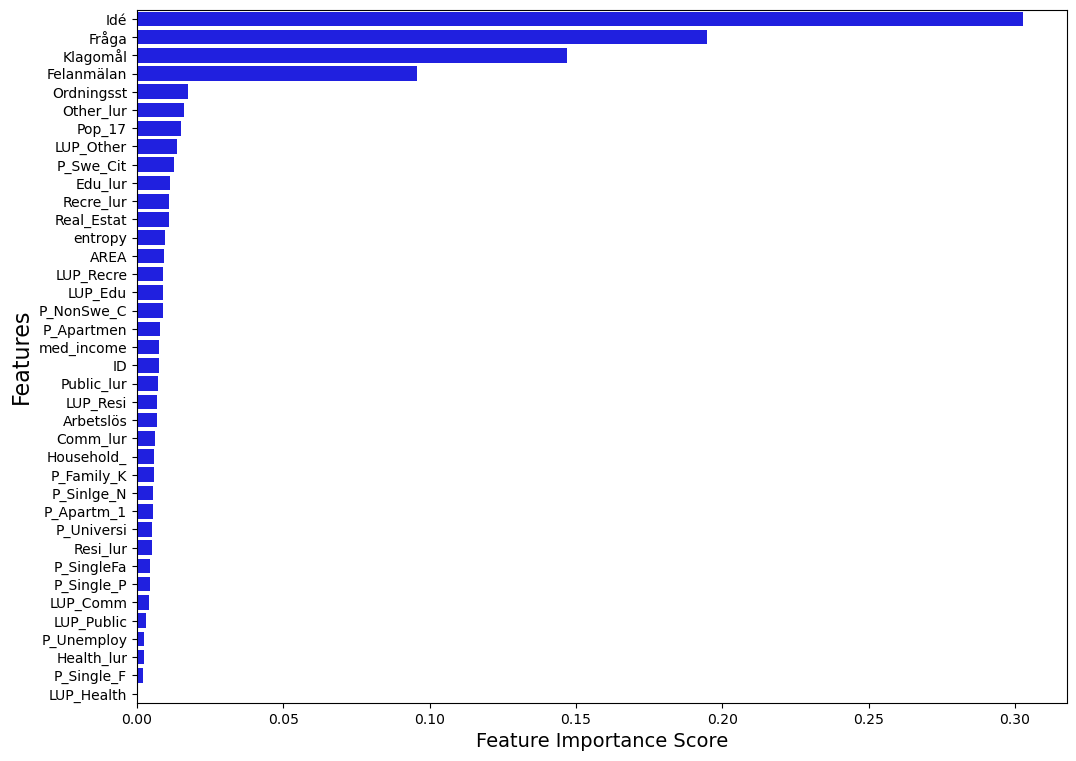

In [25]:
result1 = pd.DataFrame({"features":independent_vars, "importances":model.feature_importances_})
result = result1.sort_values(by='importances',ascending=False)
plt.figure(figsize=(12,9))
sns.barplot(x=result['importances'], y=result['features'], color='blue')
plt.xlabel('Feature Importance Score', fontsize='14')
plt.ylabel('Features', fontsize='16')
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)

In [26]:
df = data[selected_columns]
data.head()

,AREA,ID,Name,Pop_17,Male,Female,Males_15_3,Pop_65,med_income,WorkForce_,...,LUP_Edu,LUP_Health,entropy,Resi_lur,Comm_lur,Edu_lur,Recre_lur,Public_lur,Health_lur,Other_lur
0,3853125.740,2242160,Norra Akalla,110,63,47,5,0,0,29,...,0.0,0.0,0.812440,0.000010,0.352000,0.000010,0.287857,0.100702,0.00001,0.259482
1,404366.000,2242120,Centrala Akalla,5650,2900,2750,683,816,182320,3980,...,7.0,0.0,0.990739,0.264083,0.056373,0.179909,0.115240,0.053755,0.00001,0.330700
2,721921.940,2242370,Kista Gård,1817,941,876,222,42,270215,1336,...,2.0,0.0,0.697437,0.457975,0.076985,0.040123,0.017995,0.000010,0.00001,0.406972
3,2563036.437,2242130,Södra Akalla,3026,1529,1497,294,558,254532,2037,...,3.0,0.0,0.741312,0.157374,0.044464,0.060819,0.090893,0.021205,0.00001,0.625305
4,388421.500,2242220,Norra Husby,4575,2371,2204,553,527,182272,3118,...,3.0,0.0,0.998931,0.356494,0.115683,0.126595,0.113523,0.044130,0.00001,0.243636


In [31]:
from scipy.stats import pearsonr
correlation_matrix = df.corr()
p_value_matrix = np.zeros(correlation_matrix.shape)

for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[1]):
        corr, p_value = pearsonr(df.iloc[:, i], df.iloc[:, j])
        correlation_matrix.iloc[i, j] = corr
        correlation_matrix.iloc[j, i] = corr
        p_value_matrix[i, j] = p_value
        p_value_matrix[j, i] = p_value

p_value_df = pd.DataFrame(p_value_matrix, columns=correlation_matrix.columns, index=correlation_matrix.index)

correlation_matrix = correlation_matrix.round(3)
p_value_df = p_value_df.round(3)
p_value_df = p_value_df.applymap(lambda x: '***' if x < 0.001 else '**' if x < 0.05 else '*' if x < 0.1 else ' ns')

combined_table = correlation_matrix.astype(str) + p_value_df
combined_table.to_csv('correlation.csv', index=True)
combined_table

,Resi_lur,Real_Estat,Comm_lur,Other_lur,Klagomål,Pop_17,Fråga,Arbetslös,Idé,LUP_Resi,...,entropy,LUP_Recre,P_Single_P,med_income,AREA,P_NonSwe_C,P_Sinlge_N,P_Unemploy,Ordningsst,Beröm
Resi_lur,1.0***,0.452***,-0.603***,-0.041 ns,0.099**,0.243***,0.092*,0.18***,0.135**,0.66***,...,-0.133**,-0.171***,0.306***,0.148**,0.184***,-0.16**,-0.258***,-0.076 ns,-0.009 ns,0.162**
Real_Estat,0.452***,1.0***,-0.397***,0.311***,0.268***,0.202***,0.254***,0.017 ns,0.227***,0.836***,...,-0.334***,-0.087*,0.011 ns,0.228***,0.369***,-0.158**,-0.332***,-0.047 ns,0.05 ns,0.278***
Comm_lur,-0.603***,-0.397***,1.0***,-0.588***,-0.041 ns,-0.169***,-0.053 ns,-0.206***,-0.142**,-0.42***,...,-0.017 ns,-0.031 ns,-0.286***,0.087*,-0.435***,0.035 ns,0.252***,0.065 ns,0.073 ns,-0.138**
Other_lur,-0.041 ns,0.311***,-0.588***,1.0***,-0.004 ns,-0.02 ns,-0.007 ns,0.031 ns,0.046 ns,0.064 ns,...,-0.313***,-0.068 ns,0.067 ns,-0.14**,0.401***,0.05 ns,-0.204***,0.017 ns,-0.057 ns,0.023 ns
Klagomål,0.099**,0.268***,-0.041 ns,-0.004 ns,1.0***,0.559***,0.934***,0.329***,0.881***,0.225***,...,0.205***,0.212***,0.095*,0.186***,0.199***,-0.143**,0.038 ns,-0.072 ns,0.23***,0.752***
Pop_17,0.243***,0.202***,-0.169***,-0.02 ns,0.559***,1.0***,0.469***,0.861***,0.528***,0.231***,...,0.351***,0.129**,0.433***,0.064 ns,0.162**,-0.107**,-0.0 ns,-0.073 ns,0.176***,0.452***
Fråga,0.092*,0.254***,-0.053 ns,-0.007 ns,0.934***,0.469***,1.0***,0.289***,0.846***,0.215***,...,0.204***,0.196***,0.075 ns,0.162**,0.206***,-0.132**,0.04 ns,-0.068 ns,0.164**,0.754***
Arbetslös,0.18***,0.017 ns,-0.206***,0.031 ns,0.329***,0.861***,0.289***,1.0***,0.308***,0.077 ns,...,0.347***,0.092*,0.489***,-0.163**,0.155**,0.035 ns,0.022 ns,-0.013 ns,0.15**,0.269***
Idé,0.135**,0.227***,-0.142**,0.046 ns,0.881***,0.528***,0.846***,0.308***,1.0***,0.219***,...,0.257***,0.237***,0.079 ns,0.174***,0.264***,-0.171***,0.024 ns,-0.08 ns,0.148**,0.803***
LUP_Resi,0.66***,0.836***,-0.42***,0.064 ns,0.225***,0.231***,0.215***,0.077 ns,0.219***,1.0***,...,-0.243***,-0.067 ns,0.056 ns,0.205***,0.36***,-0.145**,-0.307***,-0.056 ns,0.05 ns,0.267***


# GWR for correlation

In [32]:
df.columns

Index(['Resi_lur', 'Real_Estat', 'Comm_lur', 'Other_lur', 'Klagomål', 'Pop_17',
       'Fråga', 'Arbetslös', 'Idé', 'LUP_Resi', 'P_Single_F', 'P_SingleFa',
       'ID', 'LUP_Other', 'Public_lur', 'Recre_lur', 'P_Family_K', 'Edu_lur',
       'LUP_Comm', 'Felanmälan', 'LUP_Public', 'Household_', 'P_Swe_Cit',
       'P_Apartmen', 'P_Apartm_1', 'LUP_Edu', 'LUP_Health', 'P_Universi',
       'Health_lur', 'entropy', 'LUP_Recre', 'P_Single_P', 'med_income',
       'AREA', 'P_NonSwe_C', 'P_Sinlge_N', 'P_Unemploy', 'Ordningsst',
       'Beröm'],
      dtype='object')

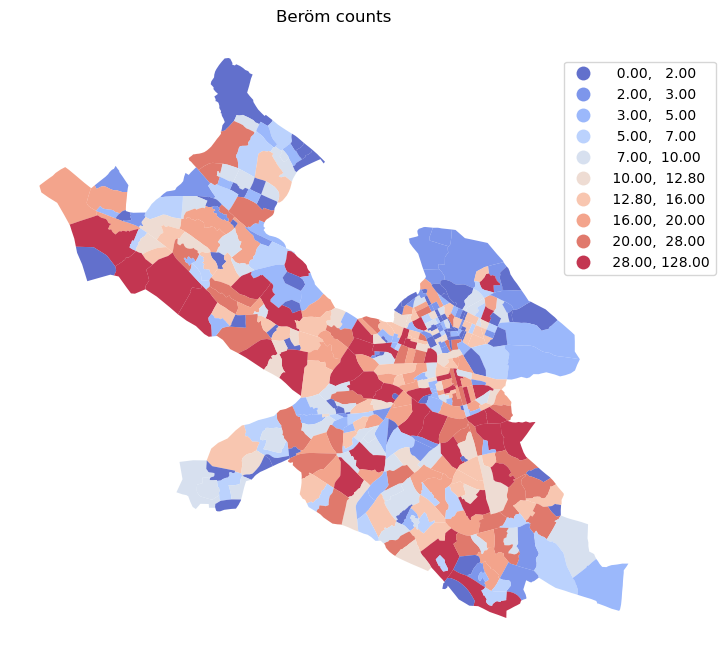

In [33]:
data['centroid'] = data.geometry.centroid
data['x'] = data['centroid'].x
data['y'] = data['centroid'].y
fig, ax = plt.subplots(figsize=(12, 8))
data.plot(column='Beröm', cmap='coolwarm', linewidth=0.01, scheme='quantiles', k=10, legend=True, 
         legend_kwds={'bbox_to_anchor': (1.10, 0.96)}, ax=ax, alpha=0.8)
ax.set_title('Beröm counts', fontsize=12)
ax.axis("off")
plt.savefig('Beröm.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
X = data[['Resi_lur', 'Real_Estat', 'Comm_lur', 'Other_lur','Arbetslös','LUP_Resi',
                     'LUP_Other', 'Public_lur', 'Recre_lur',  'Edu_lur', 'LUP_Comm',
                    'LUP_Public',  'P_Swe_Cit', 'P_Apartmen', 'LUP_Edu', 'LUP_Health',
                    'P_Universi', 'Health_lur', 'entropy', 'LUP_Recre', 'med_income','P_NonSwe_C',
                    'P_Unemploy',]].values
#'Klagomål','Fråga', 'Idé', 'Felanmälan',  'AREA',  'Ordningsst', 'Pop_17', 'P_Single_F', 'P_SingleFa','P_Single_P', 'P_Family_K','Household_',
y = data['Beröm'].values.reshape((-1,1))
u = data['x']
v = data['y']
coords = list(zip(u,v))
print(X.shape, y.shape)

(419, 23) (419, 1)


In [35]:
global_model = LinearRegression()
global_model.fit(X, y) 
global_predicted_values = global_model.predict(X)
global_mse = mean_squared_error(y, global_predicted_values)
global_mae = mean_absolute_error(y, global_predicted_values)
global_r2 = r2_score(y, global_predicted_values)

print("Global Regression MSE:", global_mse)
print("Global Regression MAE:", global_mae)
print("Global Regression R-squared:", global_r2)

Global Regression MSE: 129.60054829574844
Global Regression MAE: 6.9774676364677655
Global Regression R-squared: 0.32223769436946614


# GWR Model

In [36]:
import time
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape, y.shape)
print("Optimizing bandwidth for the GWR model...")
start_time = time.time()
gwr_selector = Sel_BW(coords, y, X_scaled)
gwr_bw = gwr_selector.search()
end_time = time.time()
print(f"Time taken for feature selection: {end_time - start_time:.2f} seconds")
print('GWR bandwidth =', gwr_bw)

(419, 23) (419, 1)
Optimizing bandwidth for the GWR model...
Time taken for feature selection: 7.25 seconds
GWR bandwidth = 217.0


In [37]:
import statsmodels.api as sm
feature_list = [
    'Resi_lur', 'Real_Estat', 'Comm_lur', 'Other_lur', 'Arbetslös',
    'LUP_Resi', 'LUP_Other', 'Public_lur', 'Recre_lur', 'Edu_lur',
    'LUP_Comm', 'LUP_Public', 'P_Swe_Cit', 'P_Apartmen',
    'LUP_Edu', 'LUP_Health', 'P_Universi', 'Health_lur',
    'entropy', 'LUP_Recre', 'med_income', 'P_NonSwe_C', 'P_Unemploy'
]

X = data[feature_list].values
y = data['Beröm'].values.reshape((-1,1))
u = data['x']
v = data['y']
coords = list(zip(u, v))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
bw = Sel_BW(coords, y, X_scaled).search()
print("GWR bandwidth =", bw)

num_cov = X_scaled.shape[1]
selected = []
start = time.time()
for step in range(num_cov):
    best_aic = np.inf
    best_j = None
    for j in range(num_cov):
        if j in selected: 
            continue
        # candidate subset + intercept
        X_cand = sm.add_constant(X_scaled[:, selected + [j]])
        aic = sm.OLS(y, X_cand).fit().aic
        if aic < best_aic:
            best_aic = aic
            best_j = j
    if best_j is None:
        break
    selected.append(best_j)
    X_sel = sm.add_constant(X_scaled[:, selected])
    _ = GWR(coords, y, X_sel, bw).fit()

end = time.time()
print(f"Stepwise took {end-start:.1f}s")
selected_feature_names = [feature_list[i] for i in selected]
print("Selected features:", selected_feature_names)

GWR bandwidth = 217.0
Stepwise took 4.4s
Selected features: ['Real_Estat', 'entropy', 'LUP_Comm', 'Arbetslös', 'P_NonSwe_C', 'Comm_lur', 'med_income', 'Edu_lur', 'LUP_Edu', 'LUP_Health', 'Public_lur', 'P_Universi', 'P_Swe_Cit', 'Other_lur', 'P_Apartmen', 'LUP_Resi', 'LUP_Public', 'Health_lur', 'LUP_Other', 'Resi_lur', 'Recre_lur', 'P_Unemploy', 'LUP_Recre']


In [38]:
from datetime import datetime
import time

start_time = time.time()
print("Current time:", datetime.now())

try:
    print("Starting GWR fitting...")
    gwr_results = GWR(coords, y, X_scaled, gwr_bw).fit()
    end_time = time.time()
    print(f"Time taken for GWR fitting: {end_time - start_time:.2f} seconds")
    print("Number of observations:", gwr_results.n)
    print("GWR Summary:")
    print(gwr_results.summary())

except Exception as e:
    print("Error encountered:", e)
    end_time = time.time()
    print(f"Time elapsed before error: {end_time - start_time:.2f} seconds")

Current time: 2025-04-19 15:57:37.022971
Starting GWR fitting...
Time taken for GWR fitting: 0.25 seconds
Number of observations: 419
GWR Summary:
Model type                                                         Gaussian
Number of observations:                                                 419
Number of covariates:                                                    24

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                          56913.496
Log-likelihood:                                                   -1623.477
AIC:                                                               3294.954
AICc:                                                              3297.950
BIC:                                                              54528.537
R2:                                                                   0.290
Adj. R2:                                                          

In [39]:
predicted_values = gwr_results.predy
actual_values = y
data['gwr_R2'] = gwr_results.localR2

mse = mean_squared_error(actual_values, predicted_values)
mae = mean_absolute_error(actual_values, predicted_values)
rmse = mse ** 0.5

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print('R2 =', gwr_results.R2)
print('AIC =', gwr_results.aic)
print('AICc =', gwr_results.aicc)
print('BIC =', gwr_results.bic)

Mean Squared Error: 67.49196854329267
Mean Absolute Error: 5.63860435610226
Root Mean Squared Error: 8.21534956914754
R2 = 0.6470422940876854
AIC = 3146.601406202656
AICc = 3204.923156809639
BIC = 3535.648874971709


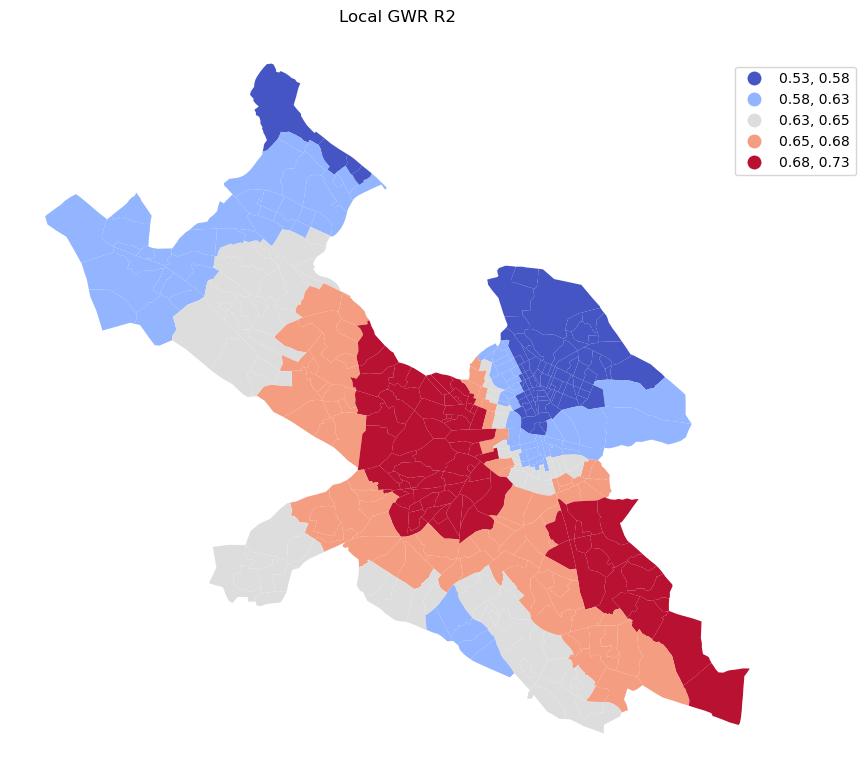

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))
data.plot(column='gwr_R2', cmap = 'coolwarm', linewidth=0.01, scheme = 'quantiles', k=5, legend=True, 
         legend_kwds={'bbox_to_anchor':(1.10, 0.96)},  ax=ax, alpha=0.95)
ax.set_title('Local GWR R2', fontsize=12)
ax.axis("off")
plt.savefig('GWR_R2.png',dpi=150, bbox_inches='tight')
plt.show()

In [49]:
feature_list = selected_feature_names

betas = gwr_results.params  # shape: (n_observations, len(feature_list) + 1)
coef_names = ['Intercept'] + feature_list
betas_df = pd.DataFrame(betas, columns=coef_names, index=data.index)
betas_df.columns

Index(['Intercept', 'Real_Estat', 'entropy', 'LUP_Comm', 'Arbetslös',
       'P_NonSwe_C', 'Comm_lur', 'med_income', 'Edu_lur', 'LUP_Edu',
       'LUP_Health', 'Public_lur', 'P_Universi', 'P_Swe_Cit', 'Other_lur',
       'P_Apartmen', 'LUP_Resi', 'LUP_Public', 'Health_lur', 'LUP_Other',
       'Resi_lur', 'Recre_lur', 'P_Unemploy', 'LUP_Recre'],
      dtype='object')

In [42]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 55 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   AREA        419 non-null    float64 
 1   ID          419 non-null    int64   
 2   Name        419 non-null    object  
 3   Pop_17      419 non-null    int64   
 4   Male        419 non-null    int64   
 5   Female      419 non-null    int64   
 6   Males_15_3  419 non-null    int64   
 7   Pop_65      419 non-null    int64   
 8   med_income  419 non-null    int64   
 9   WorkForce_  419 non-null    int64   
 10  P_Unemploy  419 non-null    float64 
 11  Arbetslös   419 non-null    int64   
 12  Arbet_Prop  419 non-null    float64 
 13  P_SweBorn   419 non-null    float64 
 14  P_NonSweBo  419 non-null    float64 
 15  P_Swe_Cit   419 non-null    float64 
 16  P_NonSwe_C  419 non-null    float64 
 17  P_Universi  419 non-null    float64 
 18  Households  419 non-null    int64   
 19  

In [43]:
betas_prefixed = betas_df.rename(columns=lambda c: f"gwr_{c}")
betas_prefixed.index = data.index
data_with_gwr = data.join(betas_prefixed)
print("Added GWR coefficient columns:")
print([col for col in data_with_gwr.columns if col.startswith("gwr_")])

Added GWR coefficient columns:
['gwr_R2', 'gwr_Intercept', 'gwr_Real_Estat', 'gwr_entropy', 'gwr_LUP_Comm', 'gwr_Arbetslös', 'gwr_P_NonSwe_C', 'gwr_Comm_lur', 'gwr_med_income', 'gwr_Edu_lur', 'gwr_LUP_Edu', 'gwr_LUP_Health', 'gwr_Public_lur', 'gwr_P_Universi', 'gwr_P_Swe_Cit', 'gwr_Other_lur', 'gwr_P_Apartmen', 'gwr_LUP_Resi', 'gwr_LUP_Public', 'gwr_Health_lur', 'gwr_LUP_Other', 'gwr_Resi_lur', 'gwr_Recre_lur', 'gwr_P_Unemploy', 'gwr_LUP_Recre']


In [46]:
data_with_gwr.columns

Index(['AREA', 'ID', 'Name', 'Pop_17', 'Male', 'Female', 'Males_15_3',
       'Pop_65', 'med_income', 'WorkForce_', 'P_Unemploy', 'Arbetslös',
       'Arbet_Prop', 'P_SweBorn', 'P_NonSweBo', 'P_Swe_Cit', 'P_NonSwe_C',
       'P_Universi', 'Households', 'P_Single_P', 'P_Sinlge_N', 'P_Family_K',
       'Properties', 'P_Apartmen', 'Real_Estat', 'P_SingleFa', 'Household_',
       'P_Single_F', 'P_Apartm_1', 'Beröm', 'Felanmälan', 'Fråga', 'Idé',
       'Klagomål', 'Ordningsst', 'geometry', 'LUP_Comm', 'LUP_Other',
       'LUP_Recre', 'LUP_Public', 'LUP_Resi', 'LUP_Edu', 'LUP_Health',
       'entropy', 'Resi_lur', 'Comm_lur', 'Edu_lur', 'Recre_lur', 'Public_lur',
       'Health_lur', 'Other_lur', 'centroid', 'x', 'y', 'gwr_R2',
       'gwr_Intercept', 'gwr_Real_Estat', 'gwr_entropy', 'gwr_LUP_Comm',
       'gwr_Arbetslös', 'gwr_P_NonSwe_C', 'gwr_Comm_lur', 'gwr_med_income',
       'gwr_Edu_lur', 'gwr_LUP_Edu', 'gwr_LUP_Health', 'gwr_Public_lur',
       'gwr_P_Universi', 'gwr_P_Swe_Cit', 'gw

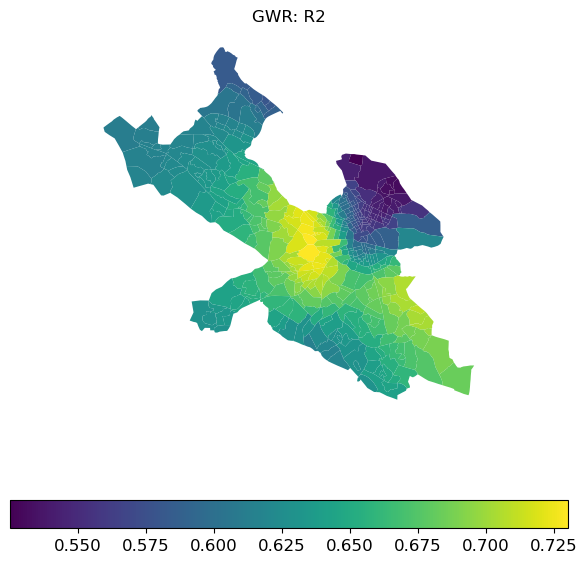

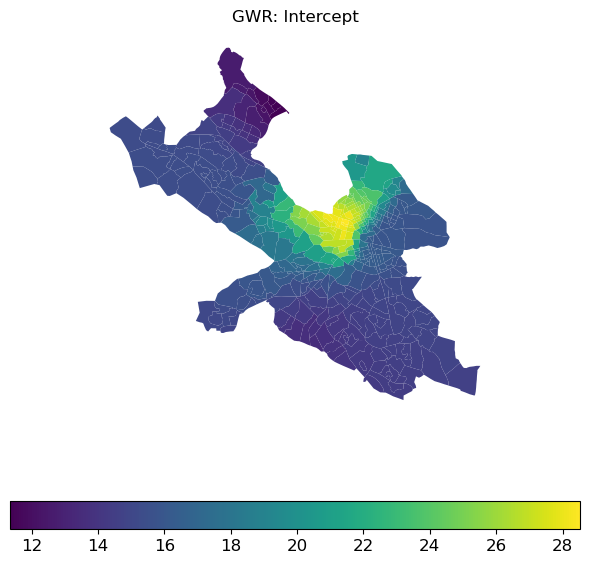

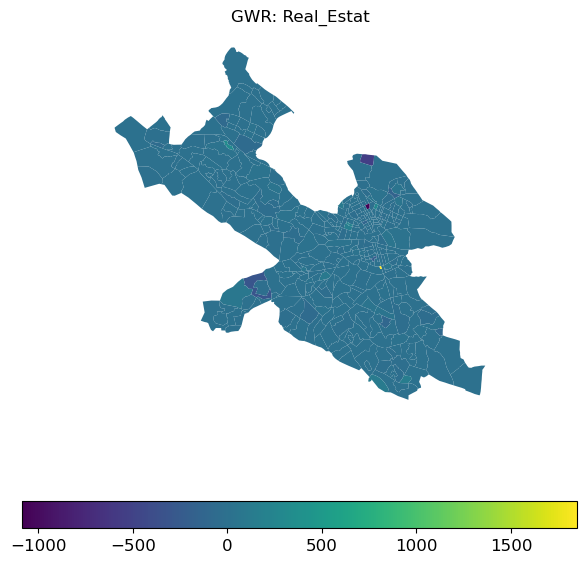

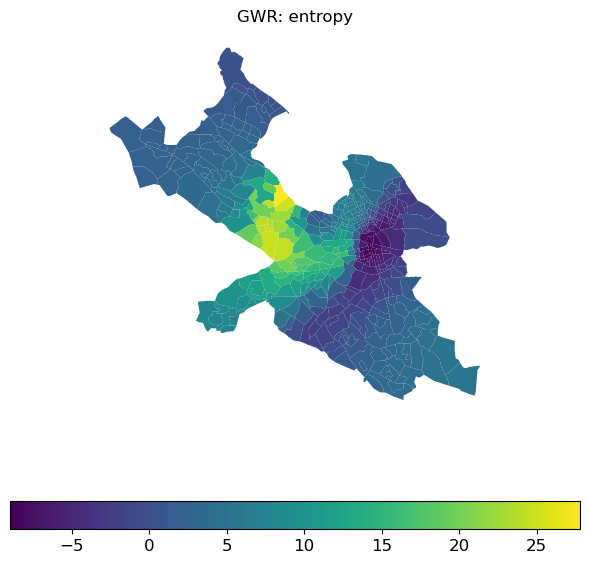

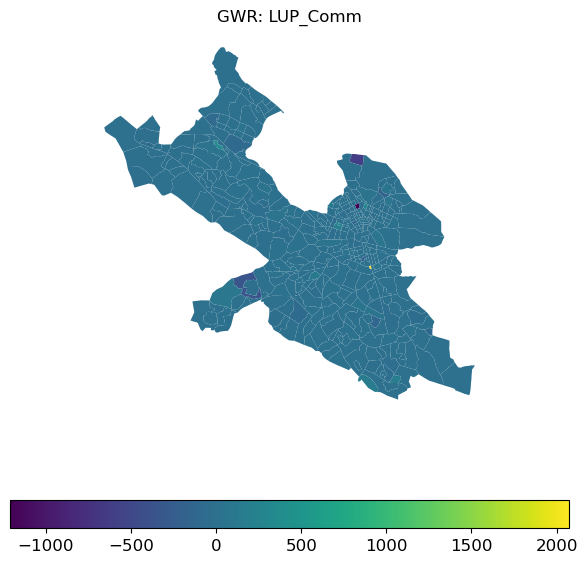

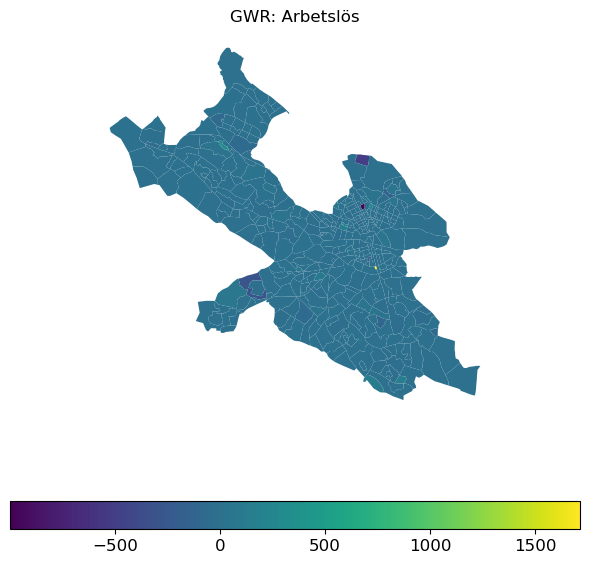

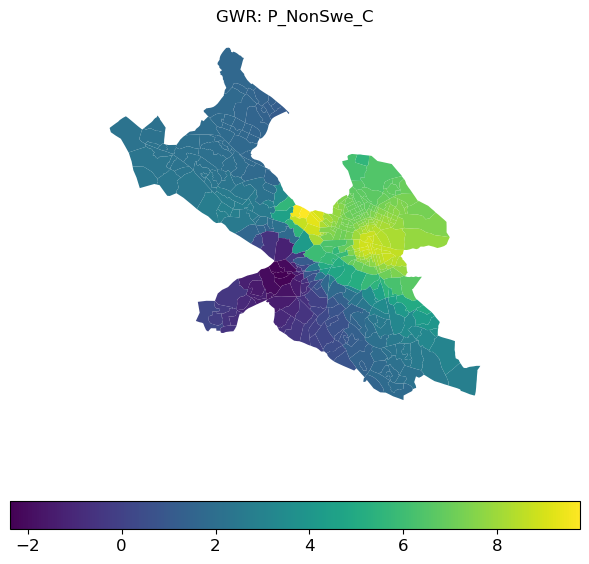

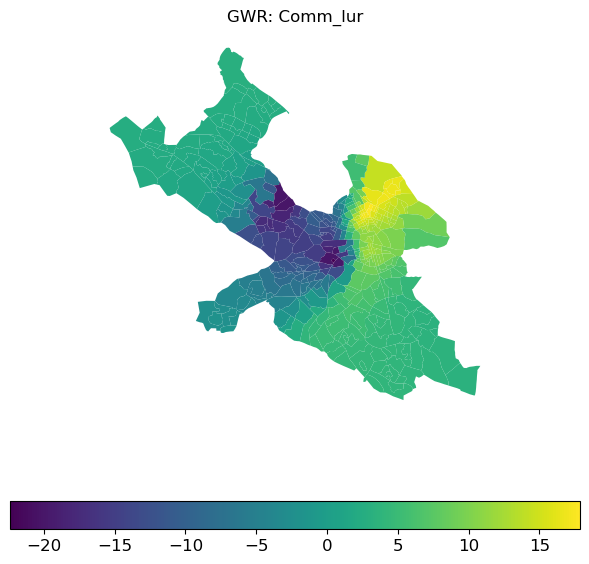

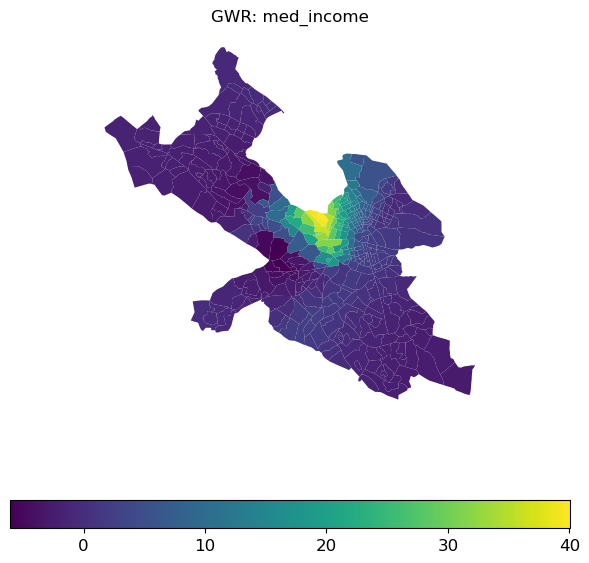

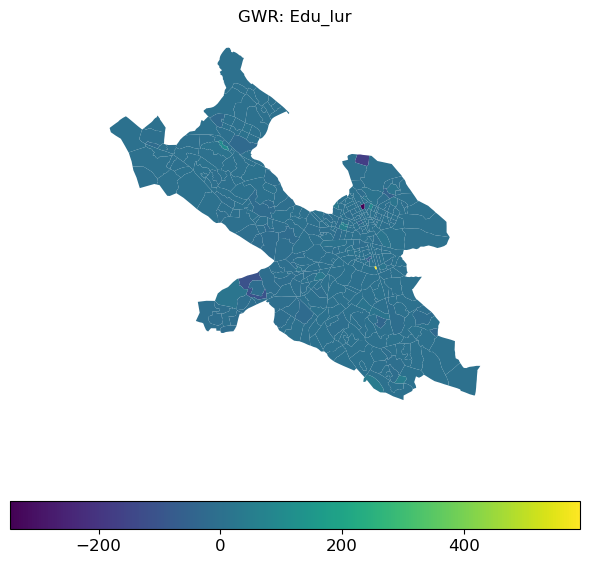

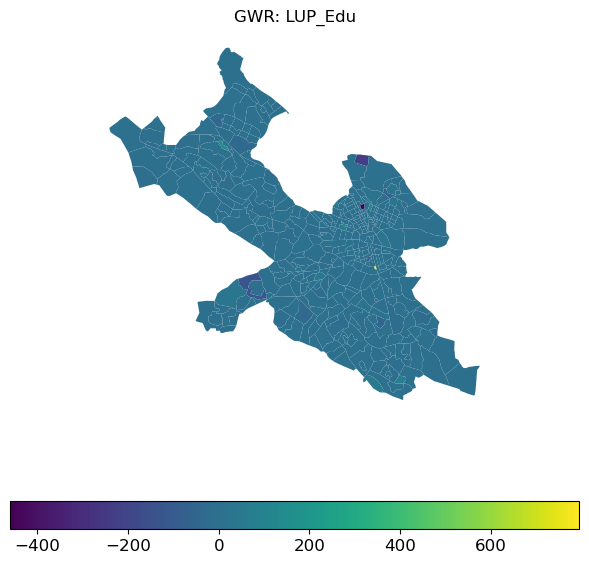

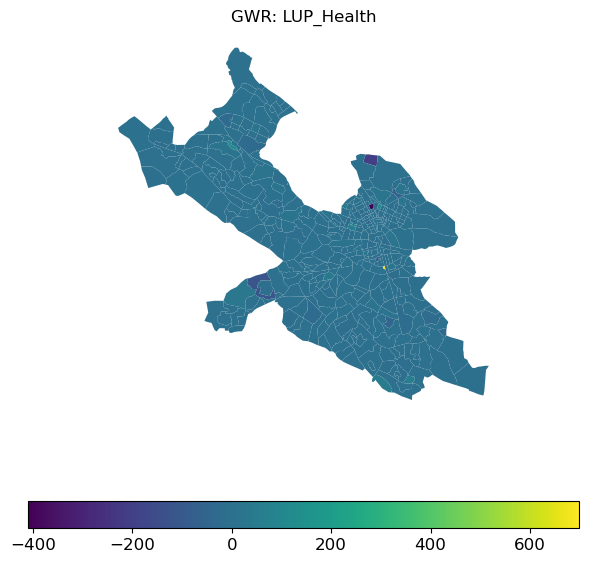

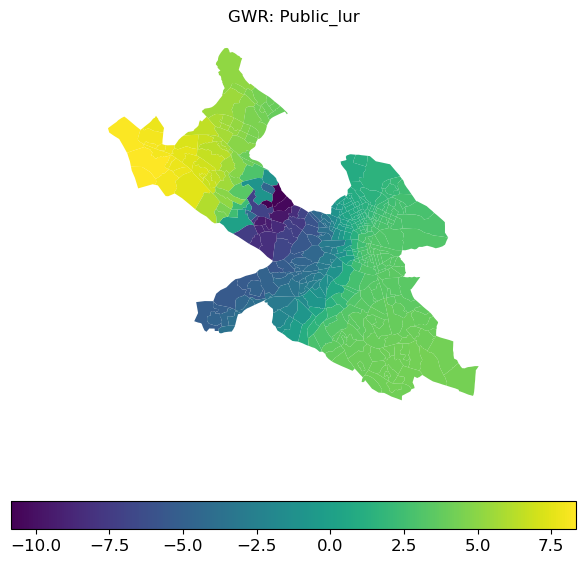

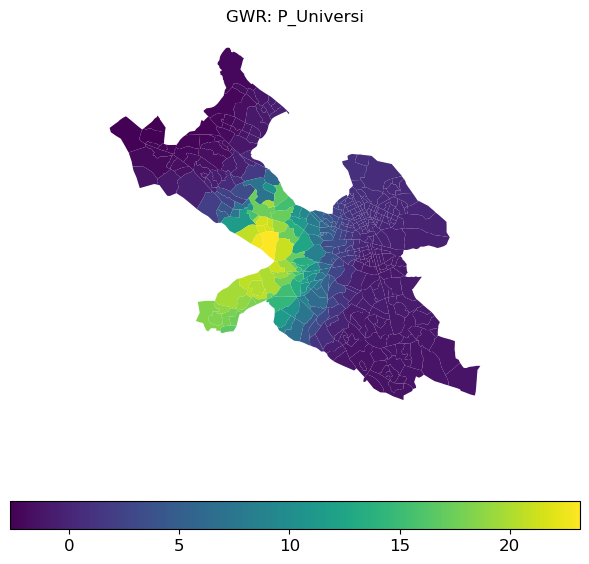

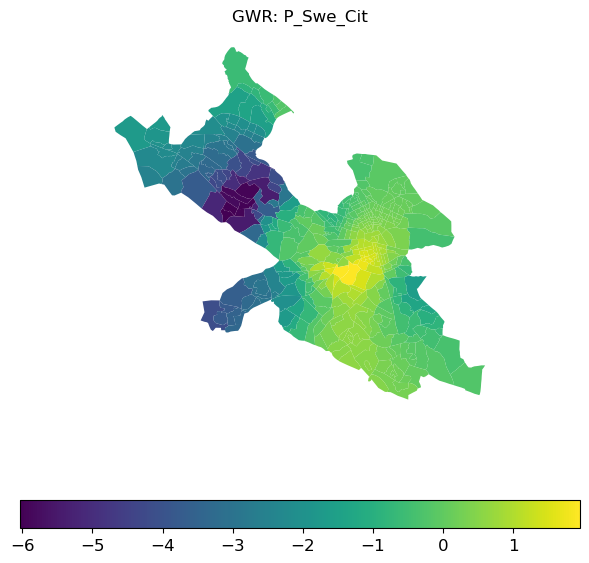

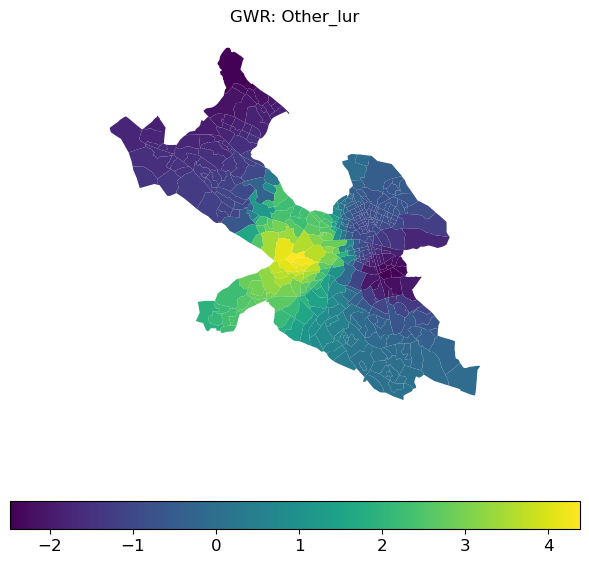

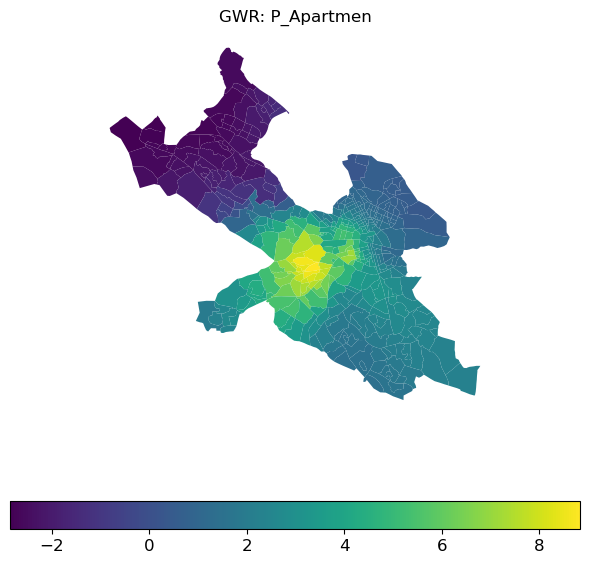

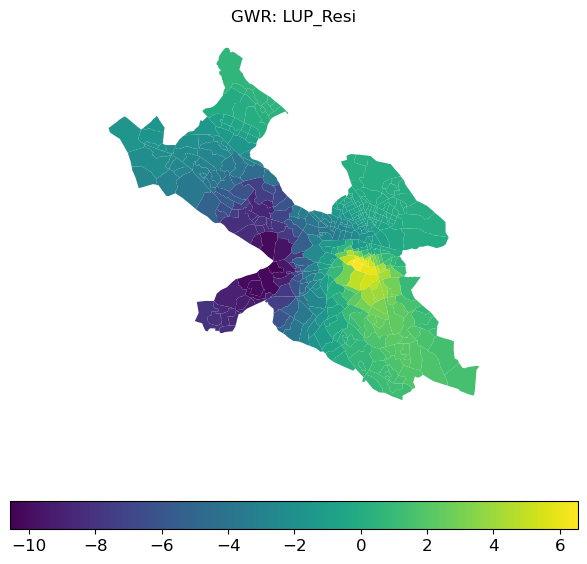

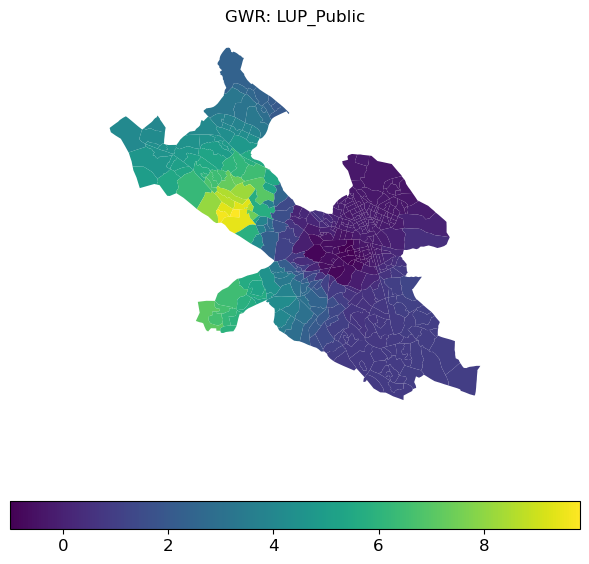

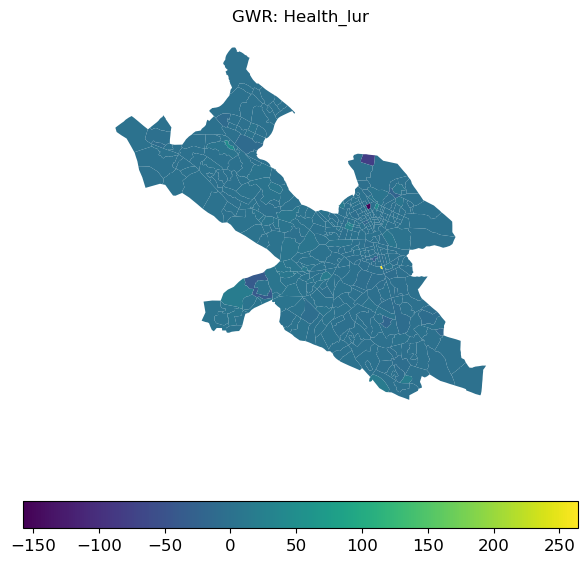

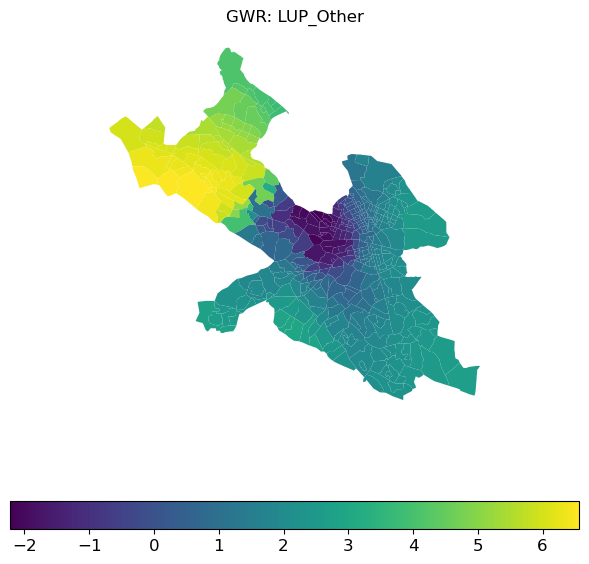

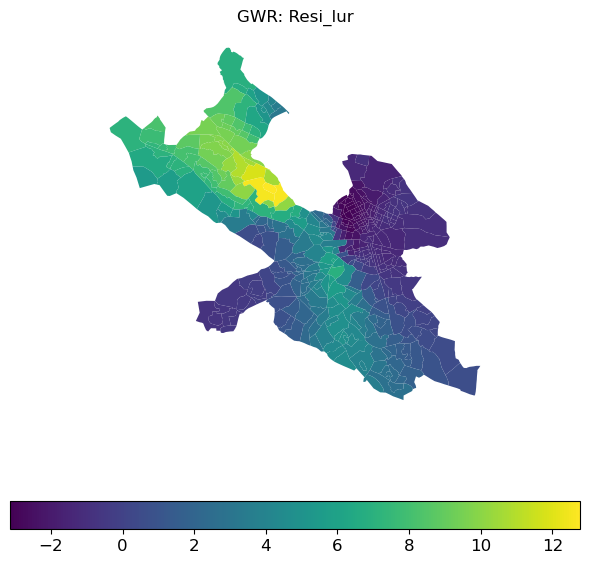

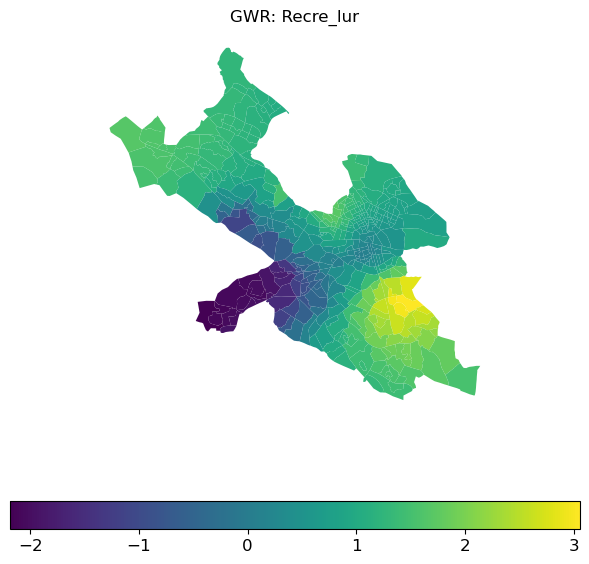

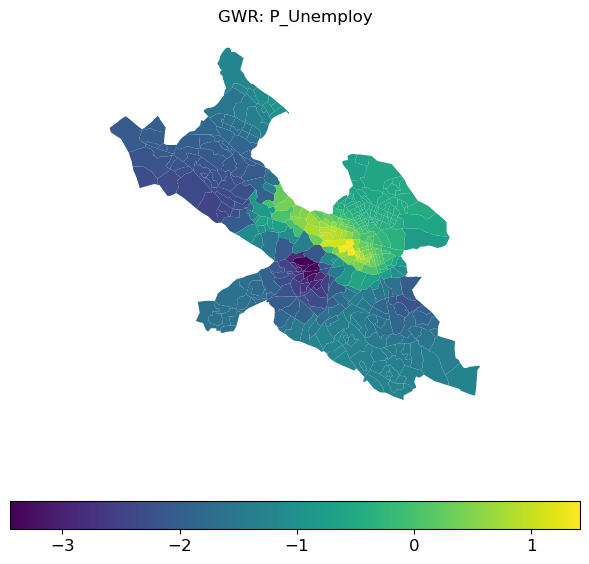

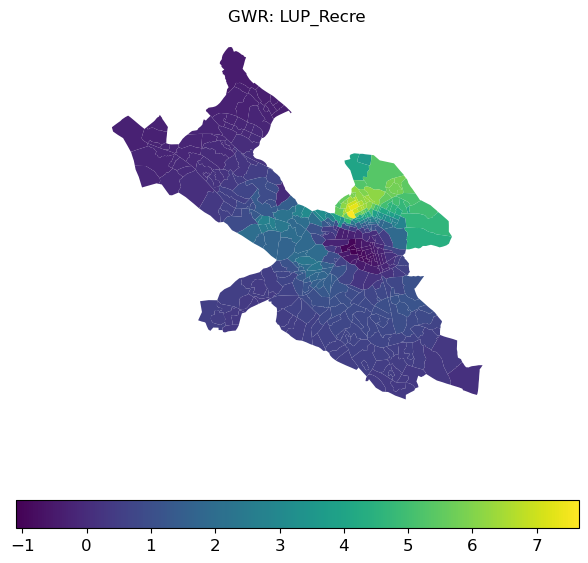

In [50]:
gwr_coefficient_cols = [col for col in data_with_gwr.columns if col.startswith('gwr_')]

for coeff_col in gwr_coefficient_cols:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    cmap = 'viridis'
    data_with_gwr.plot(column=coeff_col, cmap=cmap, linewidth=0.01, 
                legend=True, legend_kwds={'orientation': 'horizontal'},ax=ax)
    plt.tight_layout()
    ax.axis("off")
    feature_name = coeff_col.replace('gwr_', '')
    ax.set_title(f'GWR: {feature_name}', fontsize=12)
    plt.savefig(f'GWR_{feature_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

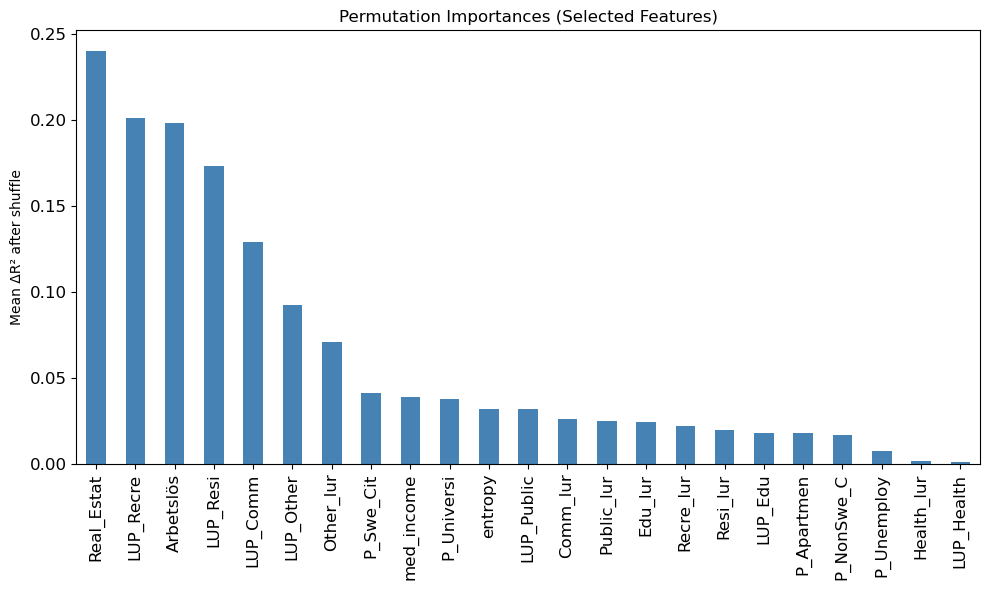

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import matplotlib.pyplot as plt

selected = [
    'Real_Estat','entropy','LUP_Comm','Arbetslös','P_NonSwe_C','Comm_lur',
    'med_income','Edu_lur','LUP_Edu','LUP_Health','Public_lur','P_Universi',
    'P_Swe_Cit','Other_lur','P_Apartmen','LUP_Resi','LUP_Public',
    'Health_lur','LUP_Other','Resi_lur','Recre_lur','P_Unemploy','LUP_Recre'
]
X_sel = data[selected]
y = data['Beröm']

rf_sel = RandomForestRegressor(n_estimators=500, random_state=42)
rf_sel.fit(X_sel, y)
perm = permutation_importance(rf_sel, X_sel, y, n_repeats=30, random_state=0, n_jobs=-1)
perm_mean = perm.importances_mean
imp_series = pd.Series(perm_mean, index=selected).sort_values(ascending=False)

plt.figure(figsize=(10,6))
imp_series.plot.bar(color='steelblue')
plt.title("Permutation Importances (Selected Features)")
plt.ylabel("Mean ΔR² after shuffle")
plt.tight_layout()
plt.savefig("perm_importance_selected.png", dpi=300)
plt.show()

for feat in selected:
    fig, ax = plt.subplots(figsize=(5,4))
    PartialDependenceDisplay.from_estimator(rf_sel, X_sel, [feat], ax=ax)
    ax.set_title(f"PDP: {feat}")
    plt.tight_layout()
    fig.savefig(f"pdp_{feat}.png", dpi=300)
    plt.close(fig)

# Temporal model

In [75]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(r'C:\Users\omkarp\Downloads\Newer\python\Shapefiles')
beromPts = "beromPoints_with_SubdivisionID.shp"
df = gpd.read_file(beromPts)
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5470 entries, 0 to 5469
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Ärendenum   5470 non-null   int64   
 1   Kategori    5470 non-null   object  
 2   Gata_Gator  5467 non-null   object  
 3   Gatunummer  5114 non-null   object  
 4   Områdesty   5470 non-null   object  
 5   Inkommet_D  5470 non-null   object  
 6   DpFeatureT  5470 non-null   object  
 7   SynpunktCo  5282 non-null   object  
 8   Koordinate  5470 non-null   float64 
 9   Koordina_1  5470 non-null   float64 
 10  Season      5470 non-null   object  
 11  Time_of_Da  5470 non-null   object  
 12  Month       5470 non-null   object  
 13  Weekday     5470 non-null   object  
 14  Year        5470 non-null   int64   
 15  Subdivisio  5462 non-null   float64 
 16  geometry    5470 non-null   geometry
dtypes: float64(3), geometry(1), int64(2), object(11)
memory usage: 726.6+ KB


In [65]:
df['Time_of_Da'].unique()

array(['Afternoon', 'Morning', 'Evening', 'Night'], dtype=object)

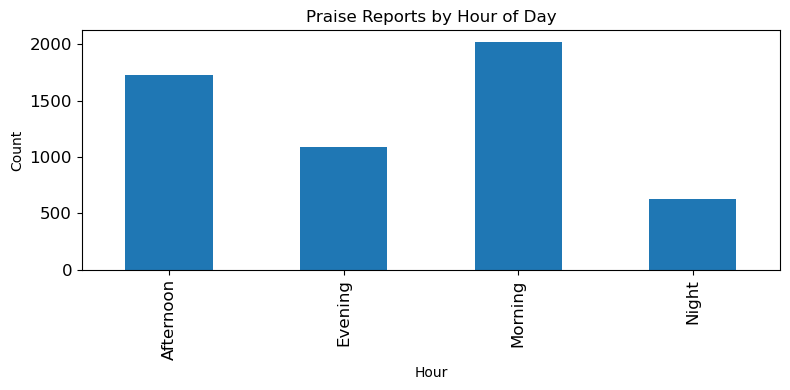

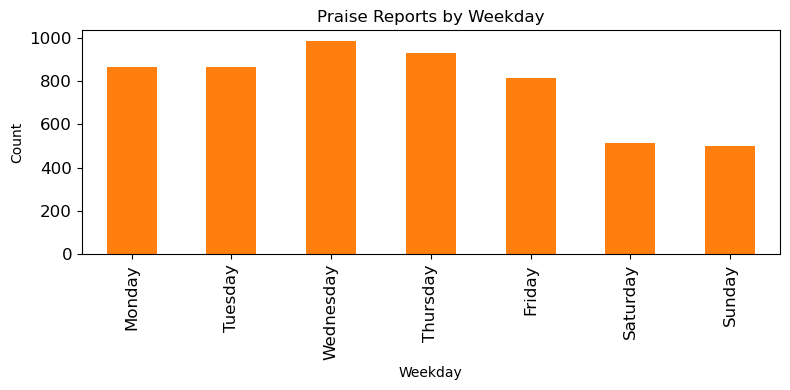

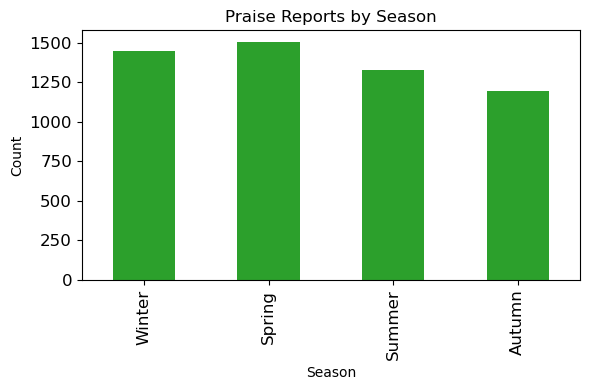

In [71]:
df['Inkommet_D'] = pd.to_datetime(df['Inkommet_D'], errors='coerce')
df = df.dropna(subset=['Inkommet_D'])

df['Hour'] = df['Inkommet_D'].dt.hour  # integer 0–23
def categorize_hour(h):
    if 6  <= h < 12: return 'Morning'
    if 12 <= h < 18: return 'Afternoon'
    if 18 <= h < 24: return 'Evening'
    return 'Night'

df['Time_of_Day'] = df['Hour'].apply(categorize_hour)
df['Weekday'] = df['Inkommet_D'].dt.day_name()
df['Month']   = df['Inkommet_D'].dt.month_name()
season_map = {
    12:'Winter', 1:'Winter', 2:'Winter',
     3:'Spring', 4:'Spring', 5:'Spring',
     6:'Summer', 7:'Summer', 8:'Summer',
     9:'Autumn',10:'Autumn',11:'Autumn'
}
df['Season'] = df['Inkommet_D'].dt.month.map(season_map)
hourly = df['Time_of_Da'].value_counts().sort_index()
plt.figure(figsize=(8,4))
hourly.plot(kind='bar', color='C0')
plt.title("Praise Reports by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

weekday = df['Weekday'].value_counts().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
plt.figure(figsize=(8,4))
weekday.plot(kind='bar', color='C1')
plt.title("Praise Reports by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

season = df['Season'].value_counts().reindex(['Winter','Spring','Summer','Autumn'])
plt.figure(figsize=(6,4))
season.plot(kind='bar', color='C2')
plt.title("Praise Reports by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [77]:
import geopandas as gpd
import pandas as pd
import numpy as np
import statsmodels.api as sm
import patsy
import matplotlib.pyplot as plt
df['Inkommet_D'] = pd.to_datetime(df['Inkommet_D'], errors='coerce')
df = df.dropna(subset=['Inkommet_D', 'Time_of_Da'])  # ensure Time_of_Da exists

df['Date'] = df['Inkommet_D'].dt.date
counts = (
    df
    .groupby(['Date','Time_of_Da'])['Ärendenum']
    .count()
    .rename('Count')
    .reset_index()
)

counts['Weekday'] = pd.to_datetime(counts['Date']).dt.day_name()
month = pd.to_datetime(counts['Date']).dt.month
season_map = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',
              9:'Autumn',10:'Autumn',11:'Autumn'}
counts['Season'] = month.map(season_map)
all_dates = pd.date_range(counts['Date'].min(), counts['Date'].max(), freq='D').date
tod_levels = ['Morning','Afternoon','Evening','Night']
idx = pd.MultiIndex.from_product([all_dates, tod_levels],
                                 names=['Date','Time_of_Da'])
counts = (
    counts
    .set_index(['Date','Time_of_Da'])
    .reindex(idx, fill_value=0)
    .reset_index()
)
counts['Weekday'] = pd.to_datetime(counts['Date']).dt.day_name()
counts['Season'] = pd.to_datetime(counts['Date']).dt.month.map(season_map)

formula = (
    "Count ~ "
    "C(Time_of_Da, Treatment(reference='Morning')) + "
    "C(Weekday,    Treatment(reference='Monday'))   + "
    "C(Season,     Treatment(reference='Winter'))"
)

y, X = patsy.dmatrices(formula, counts, return_type='dataframe')
poisson = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(poisson.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Count   No. Observations:                 7876
Model:                            GLM   Df Residuals:                     7863
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8867.4
Date:                Sat, 19 Apr 2025   Deviance:                       9997.6
Time:                        17:07:42   Pearson chi2:                 1.16e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1459
Covariance Type:            nonrobust                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

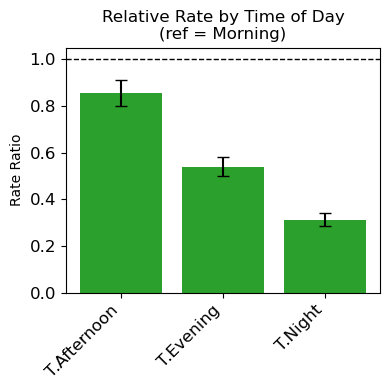

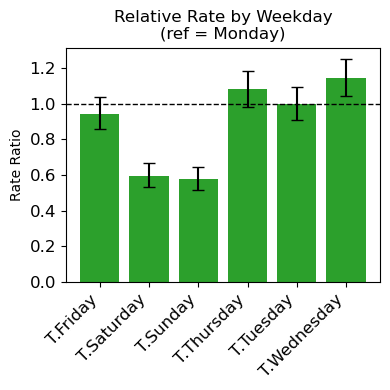

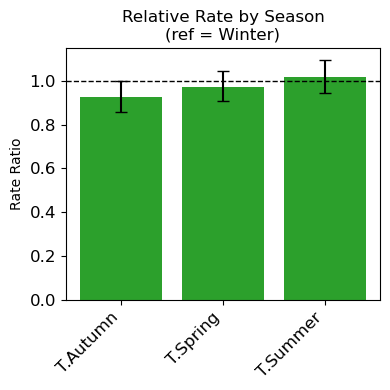

In [79]:
ci = poisson.conf_int()
ci.columns = ['lower', 'upper']

rr       = np.exp(poisson.params)         # Series, indexed by term names
rr_lower = np.exp(ci['lower'])            # Series, same index
rr_upper = np.exp(ci['upper'])            # Series, same index

def plot_rr(term_prefix, title, filename):
    subset = rr.filter(like=term_prefix)
    low    = rr_lower[subset.index]
    high   = rr_upper[subset.index]
    labels = [lbl.split('[')[1].rstrip(']') for lbl in subset.index]
    
    plt.figure(figsize=(4,4))
    plt.bar(labels, subset.values, 
            yerr=[subset.values - low.values, high.values - subset.values],
            capsize=4, color='C2')
    plt.axhline(1, color='k', linestyle='--', linewidth=1)
    plt.title(title)
    plt.ylabel("Rate Ratio")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_rr("Time_of_Da", "Relative Rate by Time of Day\n(ref = Morning)",
        "rr_time_of_day.png")

plot_rr("Weekday", "Relative Rate by Weekday\n(ref = Monday)",
        "rr_weekday.png")

plot_rr("Season", "Relative Rate by Season\n(ref = Winter)",
        "rr_season.png")